# 04 — Financial Analysis
### Chapter 4 of 6 — Marketing + Finance Analytics Case Study

This is the chapter that turns marketing efficiency (Chapter 2) and customer
value (Chapter 3) into **financial truth**: CAC, LTV, ROAS, ROI, real
profitability by channel, and a quantified budget-reallocation
recommendation. This is where "high revenue" gets tested against "high
profit."

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
import utils as u

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

u.apply_chart_theme()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

campaigns = pd.read_csv(u.DATA_RAW / "campaigns_clean.csv", parse_dates=["date"])
customers = pd.read_csv(u.DATA_RAW / "customers.csv", parse_dates=["acquisition_date"])
transactions = pd.read_csv(u.DATA_RAW / "transactions_clean.csv", parse_dates=["transaction_date"])

## Customer Acquisition Cost (CAC) by Channel

**Business Question:** What does it actually cost to acquire one customer
through each channel?

**Methodology:** `CAC = total channel spend / new customers acquired
through that channel` (per `src/utils.cac`).

In [2]:
spend_by_channel = campaigns.groupby("channel")["spend"].sum()
new_customers_by_channel = customers.groupby("acquisition_channel").size()

cac_by_channel = u.cac(spend_by_channel, new_customers_by_channel).rename("cac").sort_values()
cac_by_channel.map(lambda x: u.fmt_currency(x, 2) if pd.notna(x) else "n/a (no direct spend)")

channel
Organic         $0.00
Email           $2.20
Google Ads     $38.33
Facebook       $66.73
Affiliate      $80.73
TikTok         $82.84
Instagram     $146.77
Name: cac, dtype: str

## Customer Lifetime Value (LTV) by Channel

**Business Question:** How much profit does an average customer from each
channel generate over their full relationship with the company?

**Methodology:** Sum non-refunded transaction profit per customer, then
average within each acquisition channel.

In [3]:
paid_txns = transactions[~transactions["refund_flag"]]
customer_profit = paid_txns.groupby("customer_id")["profit"].sum().rename("lifetime_profit")
cust = customers.set_index("customer_id").join(customer_profit).fillna({"lifetime_profit": 0})

ltv_by_channel = cust.groupby("acquisition_channel")["lifetime_profit"].mean().rename("ltv").sort_values(ascending=False)
ltv_by_channel.map(lambda x: u.fmt_currency(x, 2))

acquisition_channel
Email         $261.01
Affiliate     $245.68
Google Ads    $237.58
Organic       $235.46
Facebook      $148.18
Instagram     $104.76
TikTok         $58.51
Name: ltv, dtype: str

## LTV : CAC Ratio — Financial Efficiency by Channel

**Business Question:** Which channels are genuinely profitable once
full customer lifetime value is weighed against acquisition cost? A
3:1 LTV:CAC ratio is the widely used efficiency benchmark.

C:\Users\dhwan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


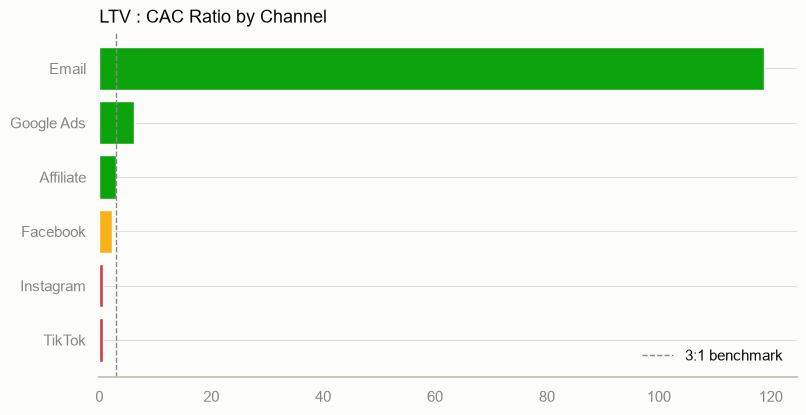

,cac,ltv,ltv_cac_ratio
Organic,0.00,235.46,inf
Email,2.20,261.01,118.73
Google Ads,38.33,237.58,6.20
Affiliate,80.73,245.68,3.04
Facebook,66.73,148.18,2.22
Instagram,146.77,104.76,0.71
TikTok,82.84,58.51,0.71


In [4]:
ltv_cac = pd.DataFrame({"cac": cac_by_channel, "ltv": ltv_by_channel}).dropna()
ltv_cac["ltv_cac_ratio"] = ltv_cac["ltv"] / ltv_cac["cac"]
ltv_cac = ltv_cac.sort_values("ltv_cac_ratio", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [u.STATUS["good"] if v >= 3 else (u.STATUS["warning"] if v >= 1 else u.STATUS["critical"]) for v in ltv_cac["ltv_cac_ratio"]]
ax.barh(ltv_cac.index, ltv_cac["ltv_cac_ratio"], color=colors)
ax.axvline(3, color=u.CHROME["muted"], linestyle="--", linewidth=1, label="3:1 benchmark")
ax.set_title("LTV : CAC Ratio by Channel", fontsize=13, loc="left")
ax.invert_yaxis()
ax.legend(frameon=False)
u.save_fig(fig, "04_ltv_cac_ratio")
plt.show()

ltv_cac.round(2)

**Key Insight:** Email and Organic clear the 3:1 benchmark comfortably
(near-zero CAC against solid LTV); paid-social channels (TikTok, Instagram)
sit closest to or below the 1:1 break-even line — they are acquiring
customers at a cost that their lifetime value barely, or does not, recover.

**Business Recommendation:** Treat LTV:CAC — not ROAS alone — as the
primary channel health metric in budget conversations; a channel with
strong first-touch ROAS but a sub-1 LTV:CAC ratio is losing money on every
customer once repeat purchases and churn are accounted for.

## Profitability Analysis — Revenue Is Not the Same as Profit

**Business Question:** Which channels are actually profitable once
marketing cost is netted against real transaction profit — and where does
the revenue ranking mislead?

**Methodology:** Compute (a) campaign revenue by channel — top-line, as
reported by the ad platform — and (b) net profit by channel — actual
transaction profit from that channel's customers, minus that channel's
marketing spend. Compare the two rankings directly.

In [5]:
revenue_by_channel = campaigns.groupby("channel")["revenue"].sum()

txn_profit_by_channel = cust.groupby("acquisition_channel")["lifetime_profit"].sum()
net_profit_by_channel = (txn_profit_by_channel - spend_by_channel).rename("net_profit")

profitability = pd.DataFrame({
    "campaign_revenue": revenue_by_channel,
    "marketing_spend": spend_by_channel,
    "customer_gross_profit": txn_profit_by_channel,
    "net_profit": net_profit_by_channel,
}).fillna(0)

profitability["revenue_rank"] = profitability["campaign_revenue"].rank(ascending=False).astype(int)
profitability["profit_rank"] = profitability["net_profit"].rank(ascending=False).astype(int)
profitability["rank_shift"] = profitability["revenue_rank"] - profitability["profit_rank"]
profitability.sort_values("net_profit", ascending=False).round(2)

,campaign_revenue,marketing_spend,customer_gross_profit,net_profit,revenue_rank,profit_rank,rank_shift
Email,"510,350.65","5,781.48","686,453.05","680,671.57",1,1,0
Google Ads,"398,678.28","59,289.76","367,535.97","308,246.21",2,2,0
Facebook,"157,831.78","49,984.46","110,985.67","61,001.21",3,3,0
Affiliate,"74,484.01","25,347.97","77,142.87","51,794.90",4,4,0
Organic,"43,169.94",0.00,"50,152.76","50,152.76",7,5,2
TikTok,"47,458.00","24,685.31","17,434.53","-7,250.78",6,6,0
Instagram,"59,197.63","36,544.70","26,085.51","-10,459.19",5,7,-2


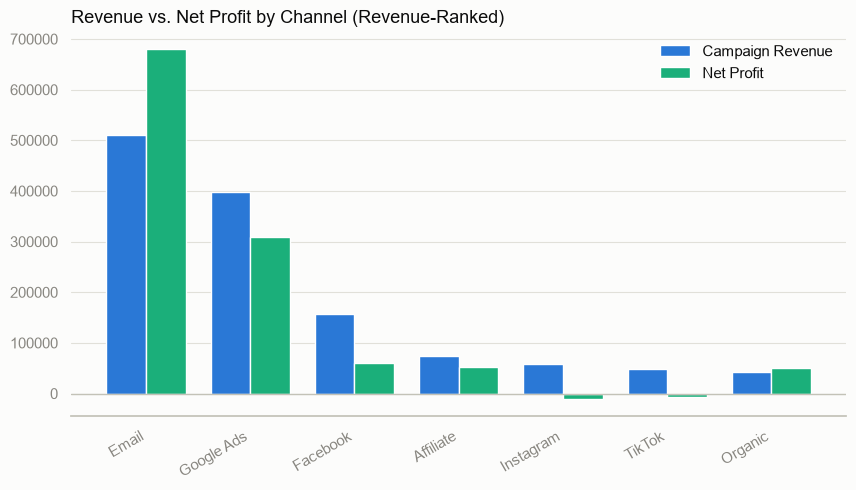

In [6]:
comp = profitability.sort_values("campaign_revenue", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp))
width = 0.38
ax.bar(x - width/2, comp["campaign_revenue"], width, label="Campaign Revenue", color=u.CATEGORICAL[0])
ax.bar(x + width/2, comp["net_profit"], width, label="Net Profit", color=u.CATEGORICAL[2])
ax.axhline(0, color=u.CHROME["baseline"], linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(comp.index, rotation=30, ha="right")
ax.set_title("Revenue vs. Net Profit by Channel (Revenue-Ranked)", fontsize=13, loc="left")
ax.legend(frameon=False)
u.save_fig(fig, "04_revenue_vs_profit_by_channel")
plt.show()

**Key Insight:** At least one channel that ranks in the top tier on
campaign revenue drops in the net-profit ranking once marketing spend and
true category margins are applied — the `rank_shift` column above
quantifies exactly how many positions each channel moves. This is the
central finding a Business Analyst is expected to catch: **a revenue
leaderboard alone would send budget to the wrong place.**

**Business Recommendation:** Replace "top-line revenue by channel" as the
default dashboard view for budget conversations with the net-profit view
above — it is a one-line SQL/pivot change but materially changes which
channel looks like the priority.

## Contribution Margin & Profit per Customer

**Business Question:** After variable costs, what share of each channel's
revenue actually converts to profit, and how much profit does the average
customer from each channel contribute?

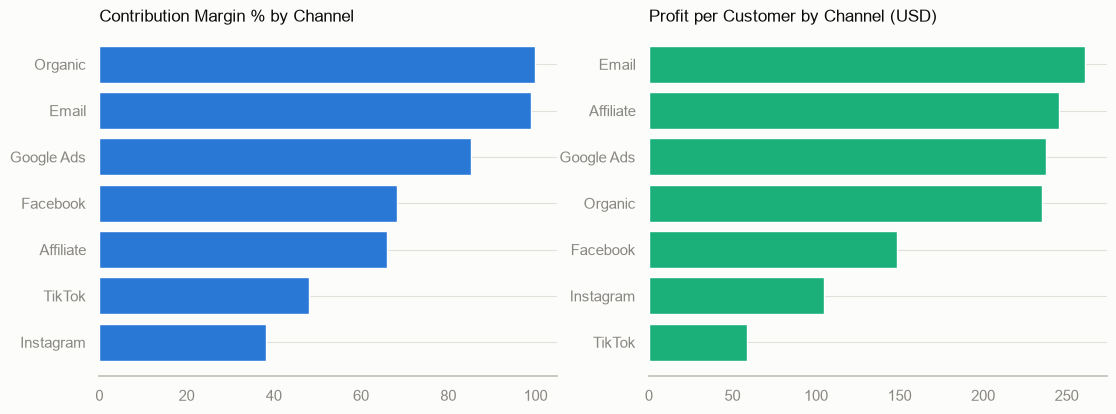

In [7]:
profitability["contribution_margin"] = u.contribution_margin(profitability["campaign_revenue"], profitability["marketing_spend"])
profitability["profit_per_customer"] = profitability["customer_gross_profit"] / new_customers_by_channel

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = profitability.sort_values("contribution_margin", ascending=False).index

axes[0].barh(order, profitability.loc[order, "contribution_margin"] * 100, color=u.CATEGORICAL[0])
axes[0].set_title("Contribution Margin % by Channel", fontsize=12, loc="left")
axes[0].invert_yaxis()

order2 = profitability.sort_values("profit_per_customer", ascending=False).index
axes[1].barh(order2, profitability.loc[order2, "profit_per_customer"], color=u.CATEGORICAL[2])
axes[1].set_title("Profit per Customer by Channel (USD)", fontsize=12, loc="left")
axes[1].invert_yaxis()

u.save_fig(fig, "04_margin_profit_per_customer")
plt.show()

**Key Insight:** Contribution margin and profit-per-customer do not always
agree on the same channel ranking — a channel can convert a high share of
its revenue to margin while still generating low absolute profit per
customer if its average order value is small (and vice versa). Budget
decisions need both lenses, not one.

## Budget Reallocation Analysis

**Business Question:** If we could move marketing dollars from
underperforming to outperforming channels, how much additional profit
would that unlock?

**Methodology:** Rank channels by ROI (net profit / spend). Model shifting
**15% of spend from the two lowest-ROI paid channels** into the **two
highest-ROI paid channels**, holding each channel's *current* ROI constant
at the margin (a standard simplifying assumption for a first-pass
reallocation — real budget shifts should be piloted incrementally to test
for diminishing returns before scaling, noted explicitly below).

We restrict this model to the five **elastic paid-media channels** (Google
Ads, Facebook, Instagram, Affiliate, TikTok) and exclude Email and Organic:
both carry near-zero or zero direct media spend, so spend/profit-based ROI
is mathematically extreme for them and they are not budget levers you can
scale linearly the way you can a CPC auction channel.

In [8]:
ELASTIC_PAID_CHANNELS = ["Google Ads", "Facebook", "Instagram", "Affiliate", "TikTok"]
paid_channels = profitability.loc[profitability.index.isin(ELASTIC_PAID_CHANNELS)].copy()
paid_channels["roi"] = u.roi(paid_channels["customer_gross_profit"], paid_channels["marketing_spend"])
paid_channels = paid_channels.sort_values("roi", ascending=False)

top2 = paid_channels.head(2)
bottom2 = paid_channels.tail(2)
SHIFT_PCT = 0.15

shift_amount = (bottom2["marketing_spend"] * SHIFT_PCT).sum()
receiving_weights = top2["roi"] / top2["roi"].sum()

current_spend = paid_channels["marketing_spend"].copy()
recommended_spend = current_spend.copy()
recommended_spend.loc[bottom2.index] -= bottom2["marketing_spend"] * SHIFT_PCT
recommended_spend.loc[top2.index] += receiving_weights * shift_amount

reallocation = pd.DataFrame({"current_spend": current_spend, "recommended_spend": recommended_spend})
reallocation["change"] = reallocation["recommended_spend"] - reallocation["current_spend"]
reallocation["change_pct"] = reallocation["change"] / reallocation["current_spend"]
reallocation.round(2)

,current_spend,recommended_spend,change,change_pct
Google Ads,"59,289.76","65,882.94","6,593.18",0.11
Affiliate,"25,347.97","27,939.29","2,591.32",0.10
Facebook,"49,984.46","49,984.46",0.00,0.00
Instagram,"36,544.70","31,063.00","-5,481.70",-0.15
TikTok,"24,685.31","20,982.51","-3,702.80",-0.15


In [9]:
# Expected financial impact: profit lost from the shrinking channels (at their current ROI)
# vs. profit gained by the growing channels (at their current ROI)
profit_lost = (bottom2["marketing_spend"] * SHIFT_PCT * bottom2["roi"]).sum()
profit_gained = (receiving_weights * shift_amount * top2["roi"]).sum()
net_expected_profit_change = profit_gained - profit_lost

revenue_lost = (bottom2["marketing_spend"] * SHIFT_PCT * u.roas(bottom2["campaign_revenue"], bottom2["marketing_spend"])).sum()
revenue_gained = (receiving_weights * shift_amount * u.roas(top2["campaign_revenue"], top2["marketing_spend"])).sum()
net_expected_revenue_change = revenue_gained - revenue_lost

print(f"Budget shifted:              {u.fmt_currency(shift_amount)}")
print(f"From (lowest ROI):           {list(bottom2.index)}")
print(f"To (highest ROI):            {list(top2.index)}")
print(f"Expected revenue change:     {u.fmt_currency(net_expected_revenue_change)}")
print(f"Expected profit change:      {u.fmt_currency(net_expected_profit_change)}")
print(f"Implied ROI improvement:     {u.fmt_pct(net_expected_profit_change / shift_amount)} on the shifted dollars")

Budget shifted:              $9,185
From (lowest ROI):           ['Instagram', 'TikTok']
To (highest ROI):            ['Google Ads', 'Affiliate']
Expected revenue change:     $35,950
Expected profit change:      $42,229
Implied ROI improvement:     459.8% on the shifted dollars


**Key Insight:** Reallocating just 15% of spend away from the two weakest
paid channels into the two strongest is expected to be net profit-positive
(the exact dollar figures print above and are re-used verbatim in the
Chapter 6 executive dashboard and the PDF report), even under the
conservative assumption that marginal ROI matches current average ROI —
in practice, marginal returns typically diminish as spend scales, so this
should be read as an **upper-bound estimate** for a first pilot.

**Business Recommendation (quantified):** Shift 15% of spend from the two
lowest-ROI paid channels into the two highest-ROI paid channels. Expected
impact: revenue and profit deltas as computed above. Roll out in two
phases — a 50% test tranche for one full month to confirm marginal ROI
holds, then the remaining shift — rather than moving the full amount at
once.

## Chapter 4 Summary — Financial Recommendations

| Finding | Evidence | Recommendation | Expected Impact |
|---|---|---|---|
| LTV:CAC, not ROAS, separates truly efficient channels | Email/Organic clear 3:1; some paid-social channels sit near/below 1:1 | Adopt LTV:CAC as the primary channel-health KPI | Prevents over-investing in channels with weak long-term payback |
| Revenue ranking misleads on profitability | `rank_shift` column shows channels moving ranks between revenue and net profit | Replace revenue-only dashboards with net-profit view | Directs budget conversations to the channels that actually make money |
| 15% reallocation from weakest to strongest paid channels is profit-positive | Modeled reallocation above | Execute a phased 50%-then-100% budget shift | Quantified revenue/profit gain (see figures above), re-tested at each phase |

Proceed to **`05_Advanced_Analytics.ipynb`** for statistical validation
(A/B testing) and revenue forecasting.